# Teste de Agente

In [1]:

# Método 1: Usando IPython.display (mais simples)
import base64
from IPython.display import Image, display, HTML
import io
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import numpy as np

# Método 3: Usando HTML diretamente
def show_img(screenshot_base64):
    html_code = f"""
    <div style="text-align: center;">
        <h3>Screenshot Capturado</h3>
        <img src="data:image/jpeg;base64,{screenshot_base64}" 
             style="max-width: 100%; height: auto; border: 1px solid #ccc;">
    </div>
    """
    display(HTML(html_code))

In [2]:
import nest_asyncio
import dotenv

dotenv.load_dotenv()

nest_asyncio.apply()

In [34]:
from typing import List, Optional
from typing_extensions import TypedDict

from langchain_core.runnables import RunnableLambda

from langchain_core.messages import BaseMessage, SystemMessage
from langgraph.graph import END, START, StateGraph
from playwright.async_api import Page

class BBox(TypedDict):
    x: float
    y: float
    text: str
    type: str
    ariaLabel: str


class Prediction(TypedDict):
    action: str
    args: Optional[List[str]]

class AgentState(TypedDict):
    page: Page  # The Playwright web page lets us interact with the web environment
    input: str  # User request
    img: str  # b64 encoded screenshot
    bboxes: List[BBox]  # The bounding boxes from the browser annotation function
    prediction: Prediction  # The Agent's output
    # A system message (or messages) containing the intermediate steps
    scratchpad: List[BaseMessage]
    observation: str  # The most recent response from a tool

graph_builder = StateGraph(AgentState)


# graph_builder.add_node("agent", agent)
# graph_builder.add_edge(START, "agent")

# graph_builder.add_node("update_scratchpad", update_scratchpad)
# graph_builder.add_edge("update_scratchpad", "agent")

In [35]:
# llm = ChatOpenAI(model="gpt-4o-mini", max_tokens=4096)
# agent = annotate | RunnablePassthrough.assign(
#     prediction=format_descriptions | prompt | llm | StrOutputParser() | parse
# )

## Old

In [48]:
import base64

from langchain_core.runnables import chain as chain_decorator

# Some javascript we will run on each step
# to take a screenshot of the page, select the
# elements to annotate, and add bounding boxes
with open("mark_page.js") as f:
    mark_page_script = f.read()


@chain_decorator
async def mark_page(page):
    await page.evaluate(mark_page_script)
    for _ in range(10):
        try:
            bboxes = await page.evaluate("markPage()")
            break
        except Exception:
            # May be loading...
            asyncio.sleep(3)
    screenshot = await page.screenshot(type="jpeg", quality=90, full_page=True)
    # Ensure the bboxes don't follow us around
    await page.evaluate("unmarkPage()")
    return {
        "img": base64.b64encode(screenshot).decode(),
        "bboxes": bboxes,
    }


async def annotate(state):
    print("annotate")
    marked_page = await mark_page.with_retry().ainvoke(state["page"])
    return {**state, **marked_page}

async def format_descriptions(state):
    """
    Formata as descrições dos bounding boxes de elementos web para uso em automação.
    
    Esta função processa uma lista de bounding boxes de elementos web e cria
    descrições textuais padronizadas, priorizando ariaLabel quando disponível
    e usando o texto do elemento como fallback.
    
    Args:
        state (dict): Estado contendo informações dos elementos web com a chave:
            - bboxes (list): Lista de dicionários, cada um representando um elemento web
              com as seguintes chaves opcionais:
                - ariaLabel (str, opcional): Label de acessibilidade do elemento
                - text (str): Texto visível do elemento
                - type (str, opcional): Tipo do elemento HTML (ex: 'button', 'input')
    
    Returns:
        dict: Estado original atualizado com nova chave:
            - bbox_descriptions (str): String formatada contendo todas as descrições
              dos elementos no formato: 'índice (<tipo/>): "texto"'
    
    Example:
        >>> state = {
        ...     "bboxes": [
        ...         {"ariaLabel": "Search button", "text": "Search", "type": "button"},
        ...         {"text": "Home", "type": "link"},
        ...         {"ariaLabel": "", "text": "Login", "type": "button"}
        ...     ]
        ... }
        >>> result = format_descriptions(state)
        >>> print(result["bbox_descriptions"])
        Valid Bounding Boxes:
        0 (<button/>): "Search button"
        1 (<link/>): "Home"
        2 (<button/>): "Login"
    
    Note:
        - A função prioriza ariaLabel sobre text para melhor acessibilidade
        - Se ariaLabel estiver vazio ou ausente, usa o texto do elemento
        - Cada elemento recebe um índice numérico sequencial (0, 1, 2, ...)
        - O formato de saída é otimizado para sistemas de automação web
    """

    labels = []
    
    # Se você quiser processar os bboxes de forma assíncrona em paralelo
    async def process_bbox(i, bbox):

        text = bbox.get("ariaLabel", "").strip() or bbox.get("text", "")
        if text:
            el_type = bbox.get("type")
            return f'{i} (<{el_type}/>): "{text}"'
        return None
    
    # Processa todos os bboxes em paralelo
    tasks = [
        process_bbox(i, bbox) 
        for i, bbox in enumerate(agent_state["bboxes"])
    ]
    
    # Aguarda todas as tarefas completarem
    results = await asyncio.gather(*tasks)
    
    # Filtra resultados válidos
    labels = [label for label in results if label is not None]
    
    bbox_descriptions = "\nValid Bounding Boxes:\n" + "\n".join(labels)
    return {**state, "bbox_descriptions": bbox_descriptions}

## DEv

In [56]:
import base64

from langchain_core.runnables import chain as chain_decorator

# Some javascript we will run on each step
# to take a screenshot of the page, select the
# elements to annotate, and add bounding boxes
with open("mark_page.js") as f:
    mark_page_script = f.read()


@chain_decorator
async def mark_page(page):
    # Injetar o script de marcação
    await page.evaluate(mark_page_script)
    
    bboxes = None  # ✅ Inicializar a variável
    
    for attempt in range(10):
        try:
            # ✅ Usar a função correta markForAI()
            bboxes = await page.evaluate("markForAI()")
            print(f"✅ Marcação bem-sucedida na tentativa {attempt + 1}")
            break
        except Exception as e:
            print(f"❌ Tentativa {attempt + 1} falhou: {e}")
            if attempt < 9:  # Não esperar na última tentativa
                await asyncio.sleep(3)  # ✅ Adicionar await
    
    if bboxes is None:
        print("❌ Falha em obter bboxes após todas as tentativas")
        # ✅ Retornar estrutura padrão em caso de falha
        bboxes = []
    
    # Capturar screenshot
    screenshot = await page.screenshot(type="jpeg", quality=90, full_page=True)
    
    # Limpar marcações
    try:
        await page.evaluate("unmarkPage()")
    except Exception as e:
        print(f"⚠️ Erro ao limpar marcações: {e}")
    
    return {
        "img": base64.b64encode(screenshot).decode(),
        "bboxes": bboxes,
    }



# ✅ Versão alternativa com mais opções
@chain_decorator
async def mark_page_with_iframes(page, include_iframe_regions=False):

    await page.evaluate(mark_page_script)
    
    bboxes = None
    
    # ✅ CORREÇÃO: Converter boolean Python para JavaScript
    options_js = f"""{{
        includeIframeRegions: {str(include_iframe_regions).lower()},
        markIframesAsClickable: true,
        executeInIframes: true
    }}"""
    
    for attempt in range(10):
        try:
            # ✅ Usar string JavaScript válida
            bboxes = await page.evaluate(f"markPageForAI({options_js})")
            print(f"✅ Marcação com iframes bem-sucedida na tentativa {attempt + 1}")
            break
        except Exception as e:
            print(f"❌ Tentativa {attempt + 1} falhou: {e}")
            if attempt < 9:
                await asyncio.sleep(3)
    
    if bboxes is None:
        print("❌ Falha em obter bboxes, tentando método básico...")
        try:
            # Fallback para método básico
            bboxes = await page.evaluate("markForAI()")
        except Exception as e:
            print(f"❌ Método básico também falhou: {e}")
            bboxes = []
    
    screenshot = await page.screenshot(type="jpeg", quality=90, full_page=True)
    
    try:
        await page.evaluate("unmarkPage()")
    except:
        pass
    
    return {
        "img": base64.b64encode(screenshot).decode(),
        "bboxes": bboxes,
        "total_elements": len(bboxes) if bboxes else 0,
        "iframe_elements": len([b for b in bboxes if b.get('isInIframe', False)]) if bboxes else 0,
        "iframe_containers": len([b for b in bboxes if b.get('isIframe', False)]) if bboxes else 0
    }    # Usar função com opções
 

async def annotate(state):
    print("annotate")
    # marked_page = await mark_page.with_retry().ainvoke(state["page"])
    # marked_page = await mark_page_with_iframes.with_retry().ainvoke(state["page"])
    marked_page = await mark_page_with_iframe_debug.with_retry().ainvoke(state["page"])
    return {**state, **marked_page}

async def format_descriptions(state):

    labels = []
    
    # Se você quiser processar os bboxes de forma assíncrona em paralelo
    async def process_bbox(i, bbox):

        text = bbox.get("ariaLabel", "").strip() or bbox.get("text", "")
        if text:
            el_type = bbox.get("type")
            return f'{i} (<{el_type}/>): "{text}"'
        return None
    
    # Processa todos os bboxes em paralelo
    tasks = [
        process_bbox(i, bbox) 
        for i, bbox in enumerate(agent_state["bboxes"])
    ]
    
    # Aguarda todas as tarefas completarem
    results = await asyncio.gather(*tasks)
    
    # Filtra resultados válidos
    labels = [label for label in results if label is not None]
    
    bbox_descriptions = "\nValid Bounding Boxes:\n" + "\n".join(labels)
    return {**state, "bbox_descriptions": bbox_descriptions}

In [57]:
import asyncio
import base64
from playwright.async_api import async_playwright

async with async_playwright() as p:
    # Lançar navegador
    browser = await p.chromium.launch(headless=True)
    
    # Criar nova página
    page = await browser.new_page()
    
    # Navegar para uma URL
    await page.goto("https://transparencia.prefeitura.rio/servidor-municipal/remuneracao/")
    
    # Capturar screenshot como JPEG base64
    screenshot_bytes = await page.screenshot(type="jpeg", quality=90, full_page=True)
    screenshot_base64 = base64.b64encode(screenshot_bytes).decode('utf-8')
    
    # Extrair conteúdo HTML
    html_content = await page.content()
    print(f"HTML Content (primeiros 200 chars): {html_content[:200]}...")

    question = "Pergunta de exemplo"

    agent_state = AgentState(
        {
            "page": page,
            "input": question,
            "scratchpad": [],
        }
    )

    agent_state = await annotate(agent_state)
    agent_state = await format_descriptions(agent_state)
    
    await simulate_click_on_element(page, 34)
    await asyncio.sleep(2)  # Aguardar carregamento
    
    # Remarcar página (pode detectar novos elementos)
    new_result = await mark_page_with_iframe_debug.with_retry().ainvoke(page)


    # await asyncio.sleep(30)
    
    # Fechar navegador
    await browser.close()

HTML Content (primeiros 200 chars): <!DOCTYPE html><html lang="pt-BR"><head>
<!-- Google Tag Manager -->

<!--<script>(function(w,d,s,l,i){w[l]=w[l]||[];w[l].push({'gtm.start':
new Date().getTime(),event:'gtm.js'});var f=d.getElementsBy...
annotate
✅ Script injetado

🔍 Diagnóstico: 0 acessíveis, 1 bloqueados

📍 Marcando elementos...

📊 RESULTADO:
   📄 Normais: 34
   📍 Em iframe: 0
   🖼️ Containers: 1
   🎯 Total: 35


TypeError: 'RunnableLambda' object is not callable

In [ ]:
new_result


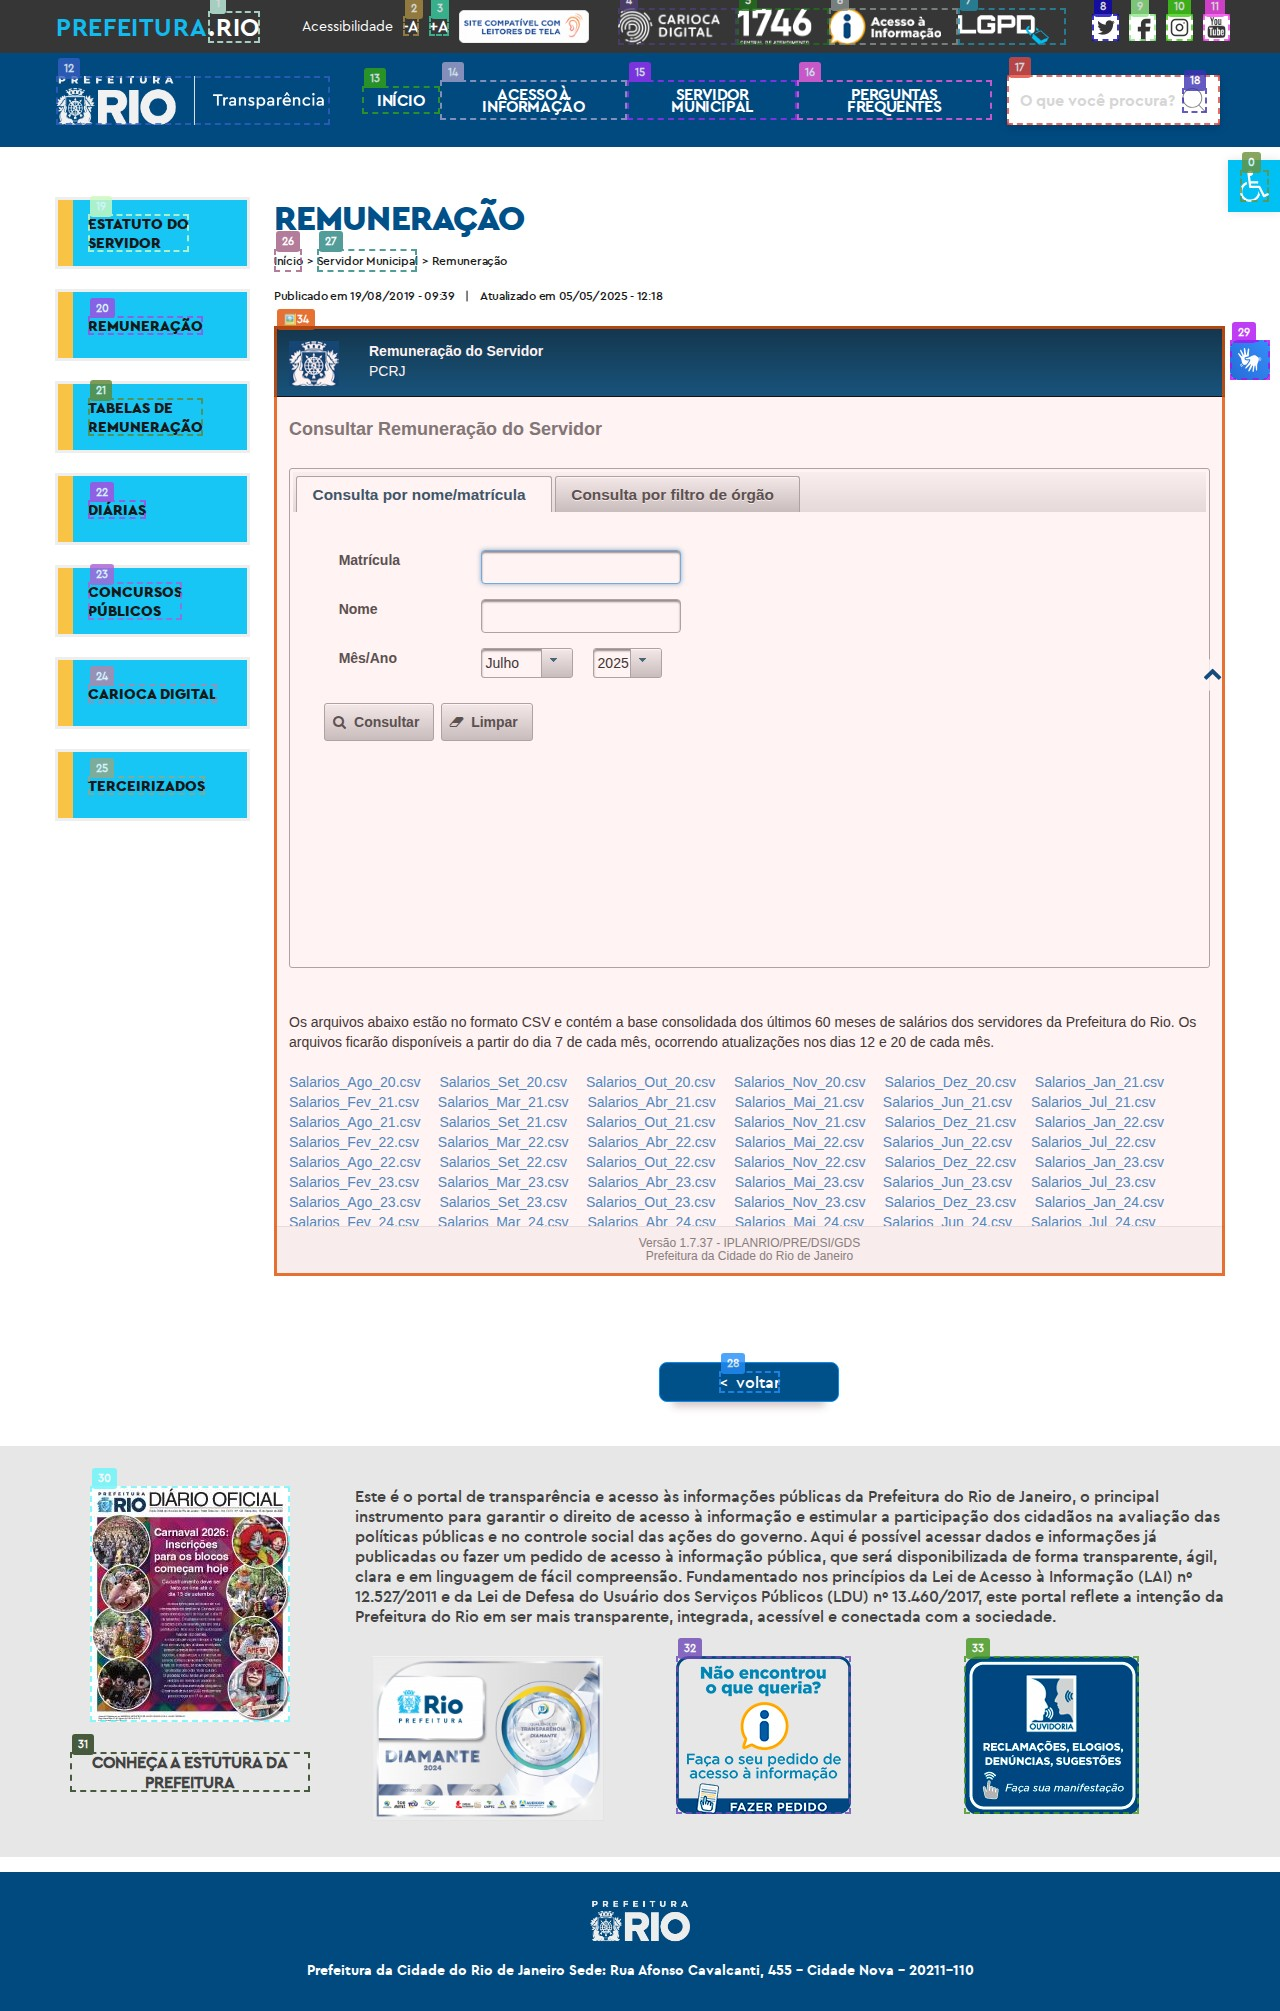

In [58]:
show_img(agent_state["img"])

In [ ]:
agent_state = await annotate_with_iframe_debug(agent_state)

In [ ]:
show_img(agent_state["img"])

In [10]:
len(agent_state["bboxes"])

34

In [12]:
with open("teste.html", "w") as f:
    f.write(html_content)
# print(html_content)

In [16]:
print(agent_state['bbox_descriptions'])


Valid Bounding Boxes:
1 (<span/>): ".RIO"
2 (<a/>): "-A"
3 (<a/>): "+A"
13 (<a/>): "INÍCIO"
14 (<a/>): "ACESSO À INFORMAÇÃO"
15 (<a/>): "SERVIDOR MUNICIPAL"
16 (<a/>): "PERGUNTAS FREQUENTES"
19 (<span/>): "ESTATUTO DO SERVIDOR"
20 (<span/>): "REMUNERAÇÃO"
21 (<span/>): "TABELAS DE REMUNERAÇÃO"
22 (<span/>): "DIÁRIAS"
23 (<span/>): "CONCURSOS PÚBLICOS"
24 (<span/>): "CARIOCA DIGITAL"
25 (<span/>): "TERCEIRIZADOS"
26 (<a/>): "Início"
27 (<a/>): "Servidor Municipal"
28 (<span/>): "< voltar"
31 (<a/>): "Conheça a Estutura da Prefeitura"


In [108]:
# agent_state['bboxes']

In [105]:
agent_state.keys()

dict_keys(['page', 'input', 'scratchpad', 'img', 'bboxes', 'bbox_descriptions'])

In [99]:
from langchain import hub

prompt = hub.pull("wfh/web-voyager")

print(prompt)

/home/eduardo/.pyenv/versions/3.11.9/lib/python3.11/site-packages/langsmith/client.py:272: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


input_variables=['bbox_descriptions', 'img', 'input'] optional_variables=['scratchpad'] input_types={'scratchpad': list[typing.Annotated[typing.Union[typing.Annotated[langchain_core.messages.ai.AIMessage, Tag(tag='ai')], typing.Annotated[langchain_core.messages.human.HumanMessage, Tag(tag='human')], typing.Annotated[langchain_core.messages.chat.ChatMessage, Tag(tag='chat')], typing.Annotated[langchain_core.messages.system.SystemMessage, Tag(tag='system')], typing.Annotated[langchain_core.messages.function.FunctionMessage, Tag(tag='function')], typing.Annotated[langchain_core.messages.tool.ToolMessage, Tag(tag='tool')], typing.Annotated[langchain_core.messages.ai.AIMessageChunk, Tag(tag='AIMessageChunk')], typing.Annotated[langchain_core.messages.human.HumanMessageChunk, Tag(tag='HumanMessageChunk')], typing.Annotated[langchain_core.messages.chat.ChatMessageChunk, Tag(tag='ChatMessageChunk')], typing.Annotated[langchain_core.messages.system.SystemMessageChunk, Tag(tag='SystemMessageChun

## Viagem do ChatGPT

In [101]:
from dataclasses import dataclass, field
from typing import List, Optional


@dataclass
class Prompt:
    system: str
    scratchpad: List[str] = field(default_factory=list)
    img: Optional[str] = None  # base64 da imagem
    bbox_descriptions: Optional[str] = None
    user_input: Optional[str] = None

    def render(self) -> str:
        """Gera o prompt final concatenando as partes."""
        scratchpad_text = "\n".join(self.scratchpad) if self.scratchpad else ""
        img_text = f"[Imagem: {self.img[:30]}...]" if self.img else ""  # truncando para debug
        return f"""\
System:
{self.system}

History:
{scratchpad_text}

Observation:
{img_text}
{self.bbox_descriptions or ''}

Input:
{self.user_input or ''}

Your reply should strictly follow the format:

Thought: {{Your brief thoughts}}
Action: {{One Action}}
"""


# ------------------------------
# Exemplo de uso
# ------------------------------

system_template = """Imagine you are a robot browsing the web, just like humans. 
You will receive a screenshot with labeled bounding boxes.
Your reply must follow this strict format:

- Click [Numerical_Label] 
- Type [Numerical_Label]; [Content] 
- Scroll [Numerical_Label or WINDOW]; [up or down] 
- Wait 
- GoBack
- Google
- ANSWER; [content]
"""

# simulação de variáveis
img_base64 = "iVBORw0KGgoAAAANSUhEUg..."  # simulando base64 da imagem
bbox_desc = "1: Search box\n2: Search button\n3: First result"
user_query = "Find the official website of LangChain"

prompt = Prompt(
    system=system_template,
    scratchpad=["Thought: I need to find LangChain website", "Action: Click 1"],
    img=img_base64,
    bbox_descriptions=bbox_desc,
    user_input=user_query,
)

print(prompt.render())


System:
Imagine you are a robot browsing the web, just like humans. 
You will receive a screenshot with labeled bounding boxes.
Your reply must follow this strict format:

- Click [Numerical_Label] 
- Type [Numerical_Label]; [Content] 
- Scroll [Numerical_Label or WINDOW]; [up or down] 
- Wait 
- GoBack
- Google
- ANSWER; [content]


History:
Thought: I need to find LangChain website
Action: Click 1

Observation:
[Imagem: iVBORw0KGgoAAAANSUhEUg......]
1: Search box
2: Search button
3: First result

Input:
Find the official website of LangChain

Your reply should strictly follow the format:

Thought: {Your brief thoughts}
Action: {One Action}



## Viagem do Claude

In [100]:
import base64
from typing import List, Dict, Optional, Union
from dataclasses import dataclass, field
from abc import ABC, abstractmethod

@dataclass
class Message:
    """Base class for messages"""
    content: str
    
@dataclass
class SystemMessage(Message):
    """System message containing instructions"""
    pass

@dataclass
class HumanMessage(Message):
    """Human message with user input"""
    pass

@dataclass
class AIMessage(Message):
    """AI response message"""
    pass

@dataclass
class ImageContent:
    """Represents image content"""
    image_data: str  # base64 encoded image
    
    def to_data_url(self) -> str:
        return f"data:image/png;base64,{self.image_data}"

class WebVoyagerPrompt:
    """
    Implementation of the web-voyager prompt without LangChain
    """
    
    def __init__(self):
        self.system_template = """Imagine you are a robot browsing the web, just like humans. Now you need to complete a task. In each iteration, you will receive an Observation that includes a screenshot of a webpage and some texts. This screenshot will
feature Numerical Labels placed in the TOP LEFT corner of each Web Element. Carefully analyze the visual
information to identify the Numerical Label corresponding to the Web Element that requires interaction, then follow
the guidelines and choose one of the following actions:

1. Click a Web Element.
2. Delete existing content in a textbox and then type content.
3. Scroll up or down.
4. Wait 
5. Go back
7. Return to google to start over.
8. Respond with the final answer

Correspondingly, Action should STRICTLY follow the format:

- Click [Numerical_Label] 
- Type [Numerical_Label]; [Content] 
- Scroll [Numerical_Label or WINDOW]; [up or down] 
- Wait 
- GoBack
- Google
- ANSWER; [content]

Key Guidelines You MUST follow:

* Action guidelines *
1) Execute only one action per iteration.
2) When clicking or typing, ensure to select the correct bounding box.
3) Numeric labels lie in the top-left corner of their corresponding bounding boxes and are colored the same.

* Web Browsing Guidelines *
1) Don't interact with useless web elements like Login, Sign-in, donation that appear in Webpages
2) Select strategically to minimize time wasted.

Your reply should strictly follow the format:

Thought: {{Your brief thoughts (briefly summarize the info that will help ANSWER)}}
Action: {{One Action format you choose}}
Then the User will provide:
Observation: {{A labeled screenshot Given by User}}"""
        
        self.scratchpad: List[Union[AIMessage, HumanMessage]] = []
    
    def format_prompt(self, 
                     img: str, 
                     bbox_descriptions: str, 
                     user_input: str,
                     scratchpad: Optional[List[Message]] = None) -> List[Message]:
        """
        Format the complete prompt with all components
        
        Args:
            img: Base64 encoded image string
            bbox_descriptions: Description of bounding boxes in the image
            user_input: User's task/query
            scratchpad: Optional conversation history
            
        Returns:
            List of formatted messages
        """
        messages = []
        
        # Add system message
        messages.append(SystemMessage(content=self.system_template))
        
        # Add scratchpad (conversation history) if provided
        if scratchpad:
            messages.extend(scratchpad)
        elif self.scratchpad:
            messages.extend(self.scratchpad)
        
        # Create human message with image and text content
        human_content = self._format_human_message(img, bbox_descriptions, user_input)
        messages.append(HumanMessage(content=human_content))
        
        return messages
    
    def _format_human_message(self, img: str, bbox_descriptions: str, user_input: str) -> str:
        """
        Format the human message combining image, bbox descriptions and user input
        """
        # In a real implementation, you'd handle the image separately
        # For this example, we'll include a placeholder for the image
        content = f"""[IMAGE: data:image/png;base64,{img}]

{bbox_descriptions}

{user_input}"""
        
        return content
    
    def add_to_scratchpad(self, message: Message):
        """Add a message to the conversation history"""
        self.scratchpad.append(message)
    
    def clear_scratchpad(self):
        """Clear the conversation history"""
        self.scratchpad.clear()
    
    def parse_action(self, response: str) -> Dict[str, str]:
        """
        Parse AI response to extract thought and action
        
        Args:
            response: AI response string
            
        Returns:
            Dict with 'thought' and 'action' keys
        """
        lines = response.strip().split('\n')
        thought = ""
        action = ""
        
        for line in lines:
            line = line.strip()
            if line.startswith("Thought:"):
                thought = line.replace("Thought:", "").strip()
            elif line.startswith("Action:"):
                action = line.replace("Action:", "").strip()
        
        return {
            "thought": thought,
            "action": action
        }
    
    def validate_action(self, action: str) -> bool:
        """
        Validate if the action follows the correct format
        
        Args:
            action: Action string to validate
            
        Returns:
            True if valid, False otherwise
        """
        valid_patterns = [
            r"Click \[\d+\]",
            r"Type \[\d+\]; .+",
            r"Scroll (?:\[\d+\]|WINDOW); (?:up|down)",
            r"Wait",
            r"GoBack",
            r"Google",
            r"ANSWER; .+"
        ]
        
        import re
        for pattern in valid_patterns:
            if re.match(pattern, action):
                return True
        return False

class WebVoyagerAgent:
    """
    Agent that uses the WebVoyagerPrompt to interact with web pages
    """
    
    def __init__(self, llm_client=None):
        self.prompt = WebVoyagerPrompt()
        self.llm_client = llm_client  # Your LLM client (OpenAI, Anthropic, etc.)
        
    def step(self, img: str, bbox_descriptions: str, user_input: str) -> Dict[str, str]:
        """
        Execute one step of web browsing
        
        Args:
            img: Base64 encoded screenshot
            bbox_descriptions: Descriptions of labeled elements
            user_input: User's task or current observation
            
        Returns:
            Dict with thought and action
        """
        # Format the prompt
        messages = self.prompt.format_prompt(img, bbox_descriptions, user_input)
        
        # Get response from LLM (implement based on your LLM client)
        if self.llm_client:
            response = self._call_llm(messages)
        else:
            # Placeholder response for demonstration
            response = """Thought: I can see a search box and need to enter a query
Action: Type [1]; python programming tutorial"""
        
        # Parse the response
        parsed = self.prompt.parse_action(response)
        
        # Validate the action
        if not self.prompt.validate_action(parsed["action"]):
            raise ValueError(f"Invalid action format: {parsed['action']}")
        
        # Add to conversation history
        self.prompt.add_to_scratchpad(HumanMessage(content=user_input))
        self.prompt.add_to_scratchpad(AIMessage(content=response))
        
        return parsed
    
    def _call_llm(self, messages: List[Message]) -> str:
        """
        Call your LLM client with the formatted messages
        This is a placeholder - implement based on your specific LLM client
        """
        # Example for OpenAI:
        # return self.llm_client.chat.completions.create(
        #     model="gpt-4-vision-preview",
        #     messages=[{"role": msg.__class__.__name__.lower().replace("message", ""), 
        #               "content": msg.content} for msg in messages]
        # ).choices[0].message.content
        
        # Example for Anthropic Claude:
        # return self.llm_client.messages.create(
        #     model="claude-3-sonnet-20240229",
        #     messages=[{"role": "user" if isinstance(msg, HumanMessage) else "assistant", 
        #               "content": msg.content} for msg in messages if not isinstance(msg, SystemMessage)]
        # ).content[0].text
        
        return "Placeholder response"

# Example usage
def main():
    """Example of how to use the WebVoyagerAgent"""
    
    # Initialize the agent
    agent = WebVoyagerAgent()
    
    # Example data (you'd get these from actual web scraping)
    screenshot_b64 = "iVBORw0KGgoAAAANSUhEUgAAAAEAAAABCAYAAAAfFcSJAAAADUlEQVR42mNkYPhfDwAChwGA60e6kgAAAABJRU5ErkJggg=="  # 1x1 pixel
    bbox_descriptions = """Bounding boxes:
[1] <input type="text" placeholder="Search..."> at (100, 200)
[2] <button>Search</button> at (300, 200)
[3] <a href="/about">About</a> at (50, 50)"""
    
    user_task = "Search for 'machine learning tutorials'"
    
    try:
        result = agent.step(screenshot_b64, bbox_descriptions, user_task)
        print("Thought:", result["thought"])
        print("Action:", result["action"])
        
        # Continue with more steps...
        
    except ValueError as e:
        print(f"Error: {e}")

if __name__ == "__main__":
    main()

Thought: I can see a search box and need to enter a query
Action: Type [1]; python programming tutorial


In [ ]:
prompt_text = """
# Prompt de Web Browsing - Português

Imagine que você é um robô navegando na web, assim como os humanos.
Agora você precisa completar uma tarefa. Em cada iteração, você receberá uma Observação que inclui uma captura de tela de uma página web e alguns textos. Esta captura de tela apresentará Rótulos Numéricos posicionados no CANTO SUPERIOR ESQUERDO de cada Elemento Web. Analise cuidadosamente a informação visual para identificar o Rótulo Numérico correspondente ao Elemento Web que requer interação, então siga as diretrizes e escolha uma das seguintes ações:

1. Clicar em um Elemento Web.
2. Deletar conteúdo existente em uma caixa de texto e depois digitar conteúdo.
3. Rolar para cima ou para baixo.
4. Esperar
5. Voltar
6. Retornar ao Google para começar de novo.
7. Responder com a resposta final

Correspondentemente, a Ação deve RIGOROSAMENTE seguir o formato:

- Click [Rótulo_Numérico]
- Type [Rótulo_Numérico]; [Conteúdo]
- Scroll [Rótulo_Numérico ou WINDOW]; [up ou down]
- Wait
- GoBack
- Google
- ANSWER; [conteúdo]

## Diretrizes Principais que você DEVE seguir:

### * Diretrizes de Ação *
1) Execute apenas uma ação por iteração.
2) Ao clicar ou digitar, certifique-se de selecionar a caixa delimitadora correta.
3) Os rótulos numéricos ficam no canto superior esquerdo de suas caixas delimitadoras correspondentes e têm a mesma cor.

### * Diretrizes de Navegação Web *
1) Não interaja com elementos web inúteis como Login, Entrar, doação que aparecem nas páginas web.
2) Selecione estrategicamente para minimizar o tempo perdido.

## Formato da Resposta

Sua resposta deve seguir rigorosamente o formato:

**Pensamento:** {{Seus pensamentos breves (resuma brevemente as informações que ajudarão a RESPONDER)}}

**Ação:** {{Um formato de Ação que você escolher}}

Então o Usuário fornecerá:

**Observação:** {{Uma captura de tela rotulada fornecida pelo Usuário}}
"""

In [96]:
print(agent_state['bbox_descriptions'])


Valid Bounding Boxes:
1 (<span/>): ".RIO"
2 (<a/>): "-A"
3 (<a/>): "+A"
13 (<a/>): "INÍCIO"
14 (<a/>): "ACESSO À INFORMAÇÃO"
15 (<a/>): "SERVIDOR MUNICIPAL"
16 (<a/>): "PERGUNTAS FREQUENTES"
29 (<span/>): "ACESSO À INFORMAÇÃO"
31 (<span/>): "BUSCA A LEGISLAÇÃO"
33 (<span/>): "DADOS ABERTOS"
35 (<span/>): "PERGUNTAS FREQUENTES"
37 (<span/>): "SERVIDOR MUNICIPAL"
39 (<span/>): "ESTRUTURA"
41 (<span/>): "CONSELHOS MUNICIPAIS"
43 (<span/>): "CONSULTA A PROCESSOS"
45 (<span/>): "CONTAS RIO"
47 (<span/>): "LICITAÇÃO"
49 (<span/>): "PAINEL DAS ORGANIZAÇÕES SOCIAIS"
51 (<span/>): "PAINEL DE OBRAS"
53 (<span/>): "PLANOS MUNICIPAIS"
55 (<span/>): "SISTEMA DE REGULAÇÃO SISREG"
57 (<span/>): "CARTA DE SERVIÇOS"
59 (<span/>): "CONTRATOS"
61 (<span/>): "PARTICIPA.RIO"
63 (<span/>): "PLANEJAMENTO E PRESTAÇÃO DE CONTAS"
65 (<span/>): "LISTA DE ESPERA CRECHES"
67 (<span/>): "SERVIÇOS DE SAÚDE"
69 (<span/>): "MEDICAMENTOS SUS"
71 (<span/>): "INSCRITOS EM DÍVIDA ATIVA"
73 (<span/>): "SITES SECRETARIAS E

In [86]:
agent_state.keys()

dict_keys(['page', 'input', 'scratchpad', 'img', 'bboxes', 'bbox_descriptions'])

In [64]:
agent_state["bbox_descriptions"][3]

'l'

In [56]:
agent_state["bboxes"][15]

{'id': 15,
 'x': 711.78125,
 'y': 100,
 'absoluteX': 711.78125,
 'absoluteY': 100,
 'type': 'a',
 'text': 'SERVIDOR MUNICIPAL',
 'ariaLabel': '',
 'inViewport': True,
 'bbox': {'left': 626.953125,
  'top': 79.53125,
  'width': 169.65625,
  'height': 40.9375},
 'scrollPosition': {'x': 0, 'y': 0},
 'pageSize': {'width': 1295, 'height': 2114},
 'viewportSize': {'width': 1280, 'height': 720}}


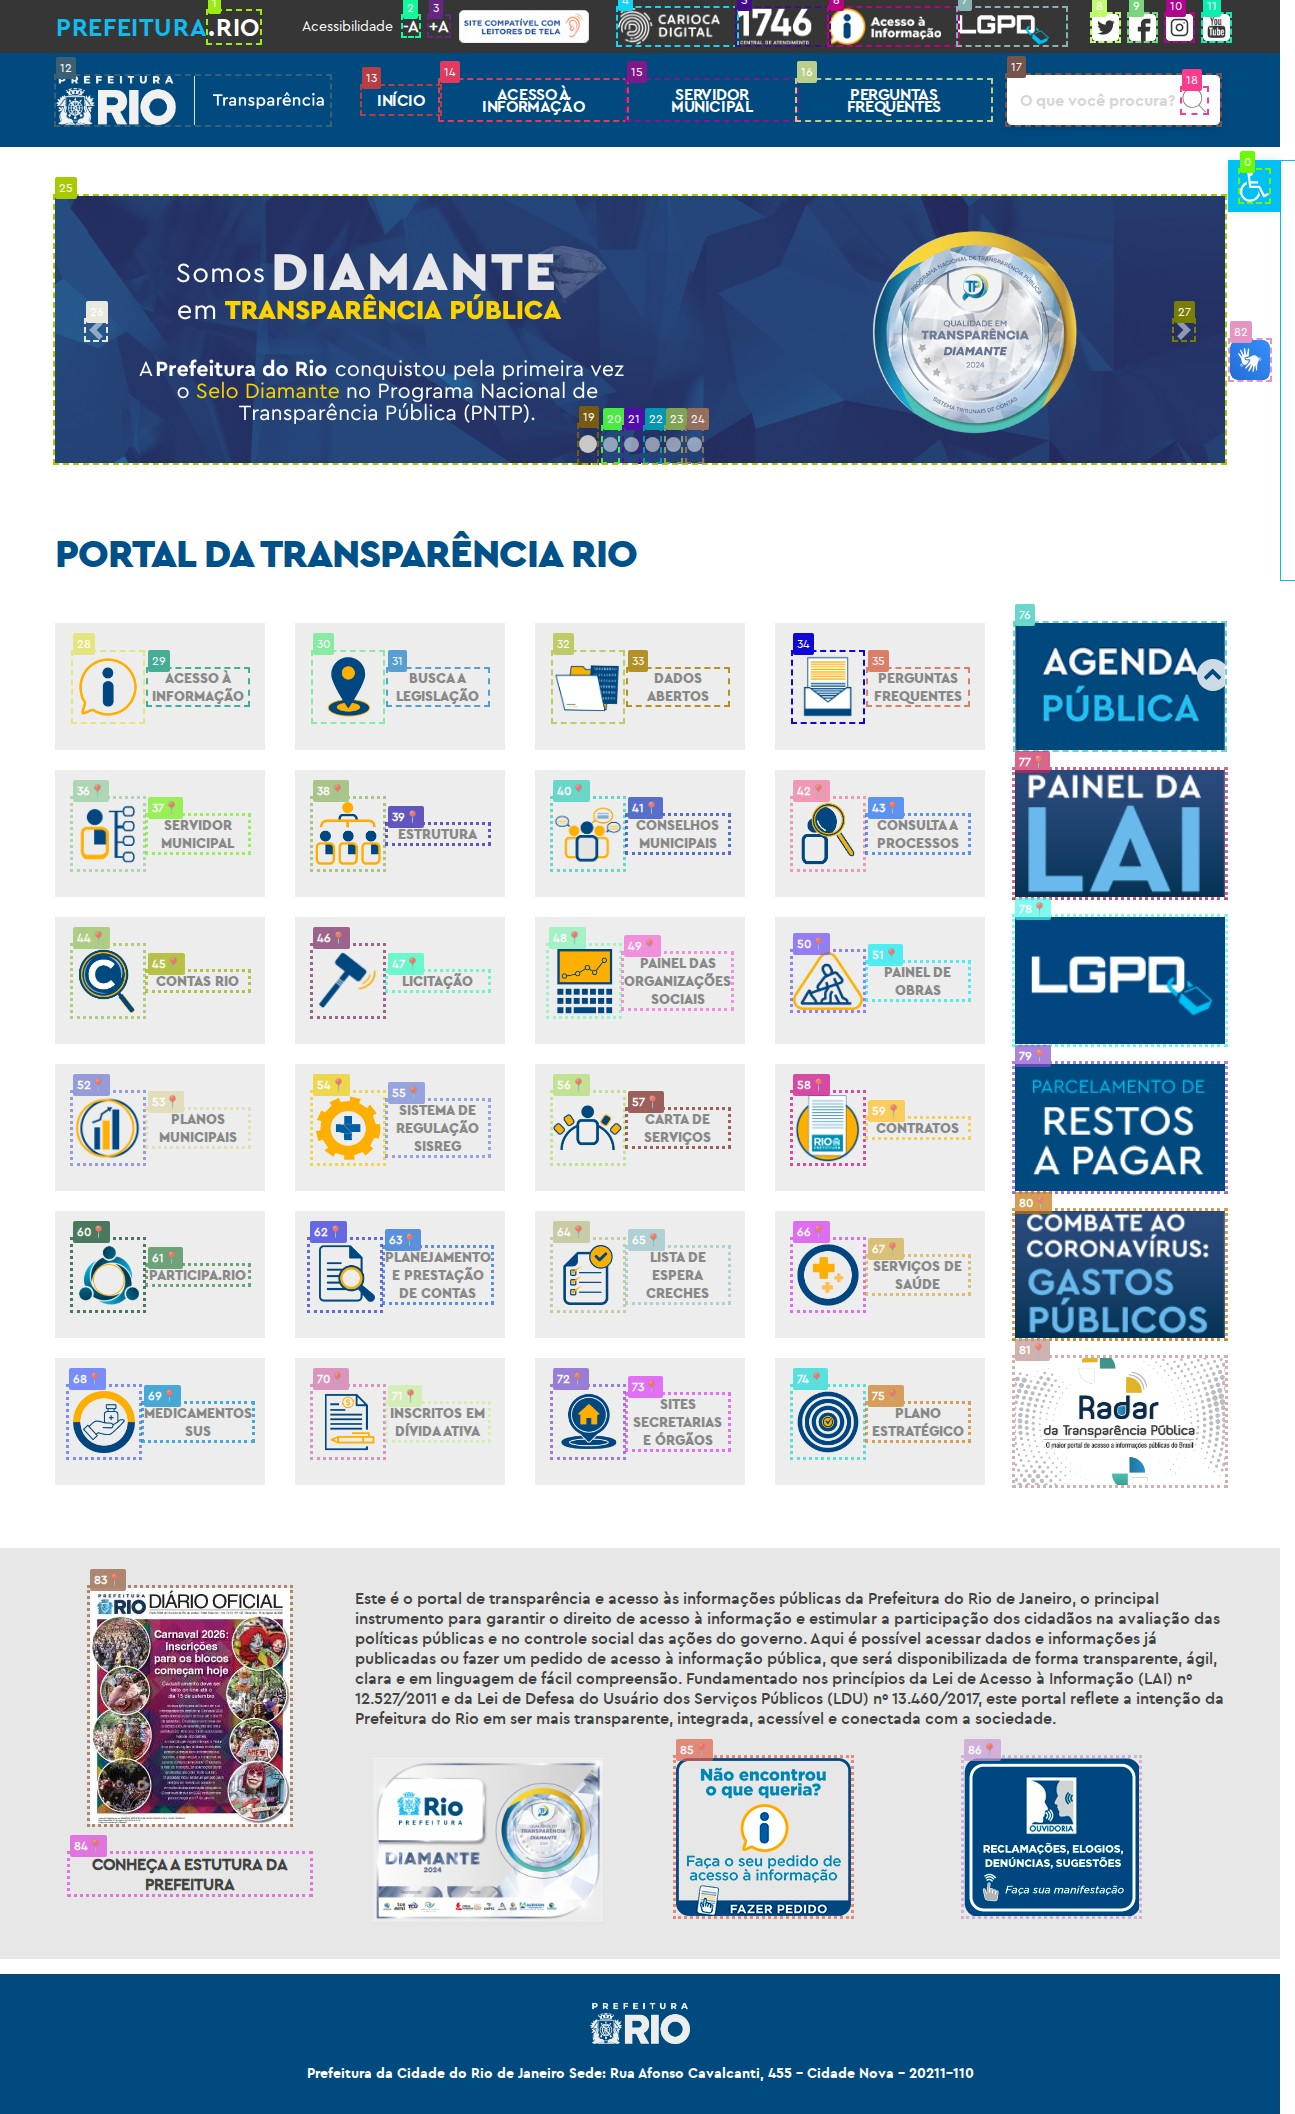

In [50]:
show_img(agent_state["img"])

In [28]:
# !pip install ipywidgets

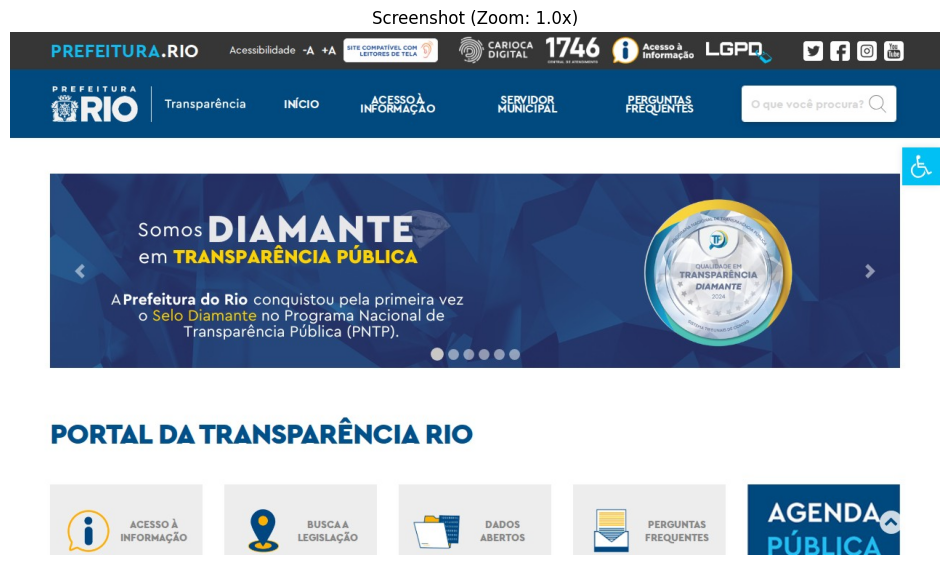

interactive(children=(FloatSlider(value=1.0, description='Zoom:', max=3.0, min=0.1), Output()), _dom_classes=(…

In [29]:
interactive_screenshot_viewer(screenshot_base64)

In [12]:
agent_state

{'page': <Page url='https://example.com/'>,
 'input': 'Pergunta de exemplo',
 'scratchpad': []}